<a href="https://colab.research.google.com/github/rodri-3004/telecom-customer-churn/blob/main/TP_Analisis_de_Metodos_Predictivos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Integrantes:
- Rodrigo Dippoliti - rodrigodippoliti@gmail.com
- Dario Rovetta - dariorovetta@gmail.com
- Lucia Santana - lucia.santana.2276@gmail.com
- Mauricio Blasetti - mauricio_blasetti@hotmail.com
- Ignacio Vespoli - vespoli.ignacio@gmail.com

## 1.- Selección del dataset:

Enlace Kaggle: https://www.kaggle.com/datasets/eshaan90/global-power-plant-database?select=global_power_plant_database.csv

Este dataset es un listado mundial de centrales eléctricas.

- 👉 Cada registro es una planta de energía.
- 👉 Describe dónde está, qué energía usa y cuánta electricidad puede producir

Sirve para entender cómo se genera la electricidad en el mundo.
- Filas: 28262
- Columnas: 22

### 1.1.- Campos del Dataset

*   **`country`** (texto): código de país de 3 caracteres correspondiente a la especificación ISO 3166-1 alfa-3
*   **`country_long`** (texto): forma larga de la designación del país
*   **`name`** (texto): nombre o título de la central eléctrica, generalmente en forma romanizada
*   **`gppd_idnr`** (texto): identificador de 10 o 12 caracteres para la central eléctrica
*   **`capacity_mw`** (número): capacidad de generación eléctrica en megavatios
*   **`latitude`** (número): geolocalización en grados decimales; WGS84 (EPSG:4326)
*   **`longitude`** (número): geolocalización en grados decimales; WGS84 (EPSG:4326)
*   **`fuel1`** (texto): fuente de energía utilizada en la generación o exportación de electricidad
*   **`fuel2`** (texto): fuente de energía utilizada en la generación o exportación de electricidad
*   **`fuel3`** (texto): fuente de energía utilizada en la generación o exportación de electricidad
*   **`fuel4`** (texto): fuente de energía utilizada en la generación o exportación de electricidad
*   **`commissioning_year`** (número): año de inicio de operaciones de la planta, ponderado por la capacidad de las unidades cuando hay datos disponibles
*   **`owner`** (texto): accionista mayoritario de la central eléctrica, generalmente en forma romanizada
*   **`source`** (texto): entidad que reporta los datos; podría ser una organización, informe o documento, generalmente en forma romanizada
*   **`url`** (texto): documento web correspondiente al campo `source`
*   **`geolocation_source`** (texto): atribución de la información de geolocalización
*   **`year_of_capacity_data`** (número): año en el que se reportó la información de capacidad
*   **`generation_gwh_2013`** (número): generación de electricidad en gigavatios-hora reportada para el año 2013
*   **`generation_gwh_2014`** (número): generación de electricidad en gigavatios-hora reportada para el año 2014
*   **`generation_gwh_2015`** (número): generación de electricidad en gigavatios-hora reportada para el año 2015
*   **`generation_gwh_2016`** (número): generación de electricidad en gigavatios-hora reportada para el año 2016
*   **`estimated_generation_gwh`** (número): generación anual estimada de electricidad en gigavatios-hora para el año 2014

### 1.2.- Lectura del dataset

In [ ]:
# Importamos las librerías que utilizaremos en el Analisis de Regresion
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# ID del archivo de Google Drive
file_id_1 = "1WOJ-x9lzU9OHyZ0n9TGUtVUeQlqoUEb_"

# Armamos la URL de descarga directa
url_1 = f"https://drive.google.com/uc?id={file_id_1}"

# Leemos el CSV
df = pd.read_csv(url_1)

# Mostramos las primeras filas del Dataset
df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,...,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN



En una primera inspección del conjunto de datos, observamos la presencia de variables redundantes, así como una cantidad de valores faltantes en otras columnas.

Comenzaremos realizando una copia de la Base de Datos y trabajaremos sobre ella.

In [ ]:
# Realizamos la copia del Dataset original como una buena practica
DATA = df.copy()

DATA.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,...,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN


#2.- Limpieza de Datos

##2.1.- Vistazo general y tipos de datos

In [ ]:
# Mostramos la información general de este Dataset: cantidad de filas, columnas, tipos de datos y uso de memoria.

print("--- Información General ---")
DATA.info()

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28664 entries, 0 to 28663
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   28664 non-null  object 
 1   country_long              28664 non-null  object 
 2   name                      28644 non-null  object 
 3   gppd_idnr                 28664 non-null  object 
 4   capacity_mw               28664 non-null  float64
 5   latitude                  28664 non-null  float64
 6   longitude                 28664 non-null  float64
 7   fuel1                     28661 non-null  object 
 8   fuel2                     1705 non-null   object 
 9   fuel3                     296 non-null    object 
 10  fuel4                     108 non-null    object 
 11  commissioning_year        14952 non-null  float64
 12  owner                     18093 non-null  object 
 13  source                    28664 n

Identificamos que el conjunto de datos está compuesto por una combinación de variables categóricas y numéricas.

## 2.2.- Detección de Valores Nulos

In [ ]:
# Contamos la cantidad de valores nulos por columna
print("\n--- Valores Nulos por Columna ---")
nulos = DATA.isnull().sum()

# Imprimimos solamente las columnas que tienen valores nulos
print(nulos[nulos > 0])

# Calculamos el porcentaje de nulos para luego decidir si imputamos o eliminamos la columna
print("\n--- Porcentaje de Nulos ---")
porcentaje_nulos = (DATA.isnull().sum() / len(df)) * 100

# Imprimimos el resultado
print(porcentaje_nulos[porcentaje_nulos > 0])


--- Valores Nulos por Columna ---
name                           20
fuel1                           3
fuel2                       26959
fuel3                       28368
fuel4                       28556
commissioning_year          13712
owner                       10571
geolocation_source            421
year_of_capacity_data       12519
generation_gwh_2013         28225
generation_gwh_2014         28209
generation_gwh_2015         27706
generation_gwh_2016         20338
estimated_generation_gwh     1128
dtype: int64

--- Porcentaje de Nulos ---
name                         0.069774
fuel1                        0.010466
fuel2                       94.051772
fuel3                       98.967346
fuel4                       99.623221
commissioning_year          47.837008
owner                       36.879012
geolocation_source           1.468741
year_of_capacity_data       43.674993
generation_gwh_2013         98.468462
generation_gwh_2014         98.412643
generation_gwh_2015         9

Tras estos resultados podemos observar que existen algunas variables que contienen una alta proporcion de valores nulos.

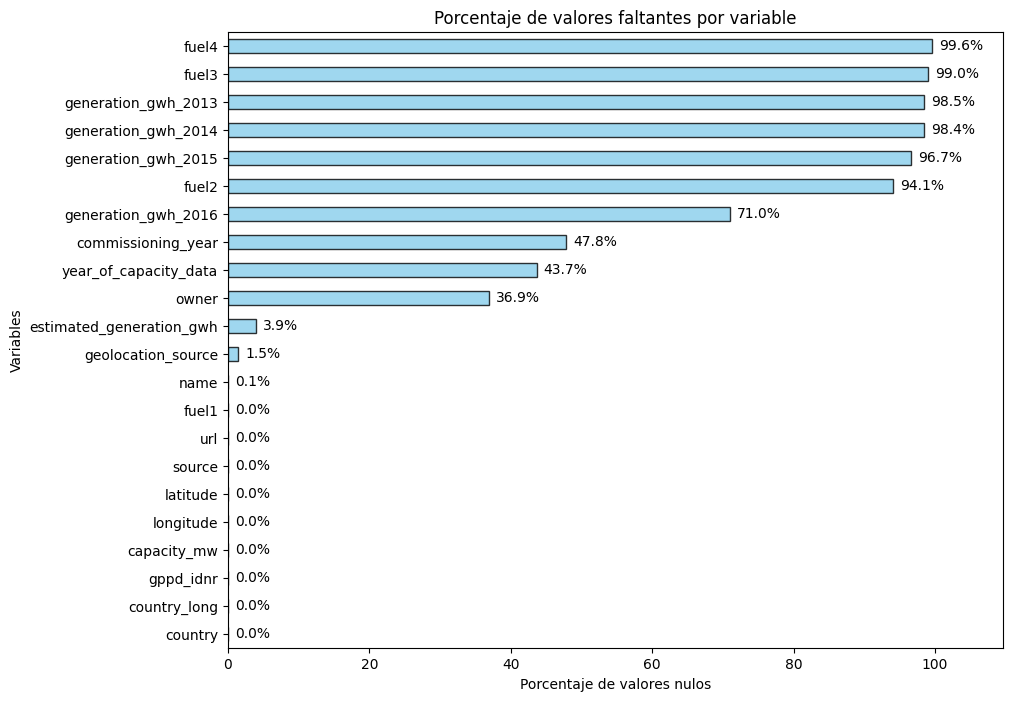

In [ ]:
porcentaje_nulos_ordenado = porcentaje_nulos.sort_values(ascending=True)

plt.figure(figsize=(10, 8))

ax = porcentaje_nulos_ordenado.plot(kind='barh', color='skyblue', edgecolor='black', alpha=0.8)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)

plt.xlabel("Porcentaje de valores nulos")
plt.ylabel("Variables")
plt.title("Porcentaje de valores faltantes por variable")

plt.xlim(0, porcentaje_nulos_ordenado.max() * 1.1)

plt.show()

##2.3.- Detección de Duplicados

In [ ]:
# Verificamos si hay filas duplicadas y cuantas hay
cantidad_duplicados = DATA.duplicated().sum()
print(f"\nCantidad de filas duplicadas: {cantidad_duplicados}")


Cantidad de filas duplicadas: 0


Con cero filas duplicadas, nos confirma que cada uno de los registros es único. Constatamos que no haya un error de carga donde aparezca una misma fila repetidas varias veces y ésto nos influya en nuestro análisis.

#3.- Preprocesamiento

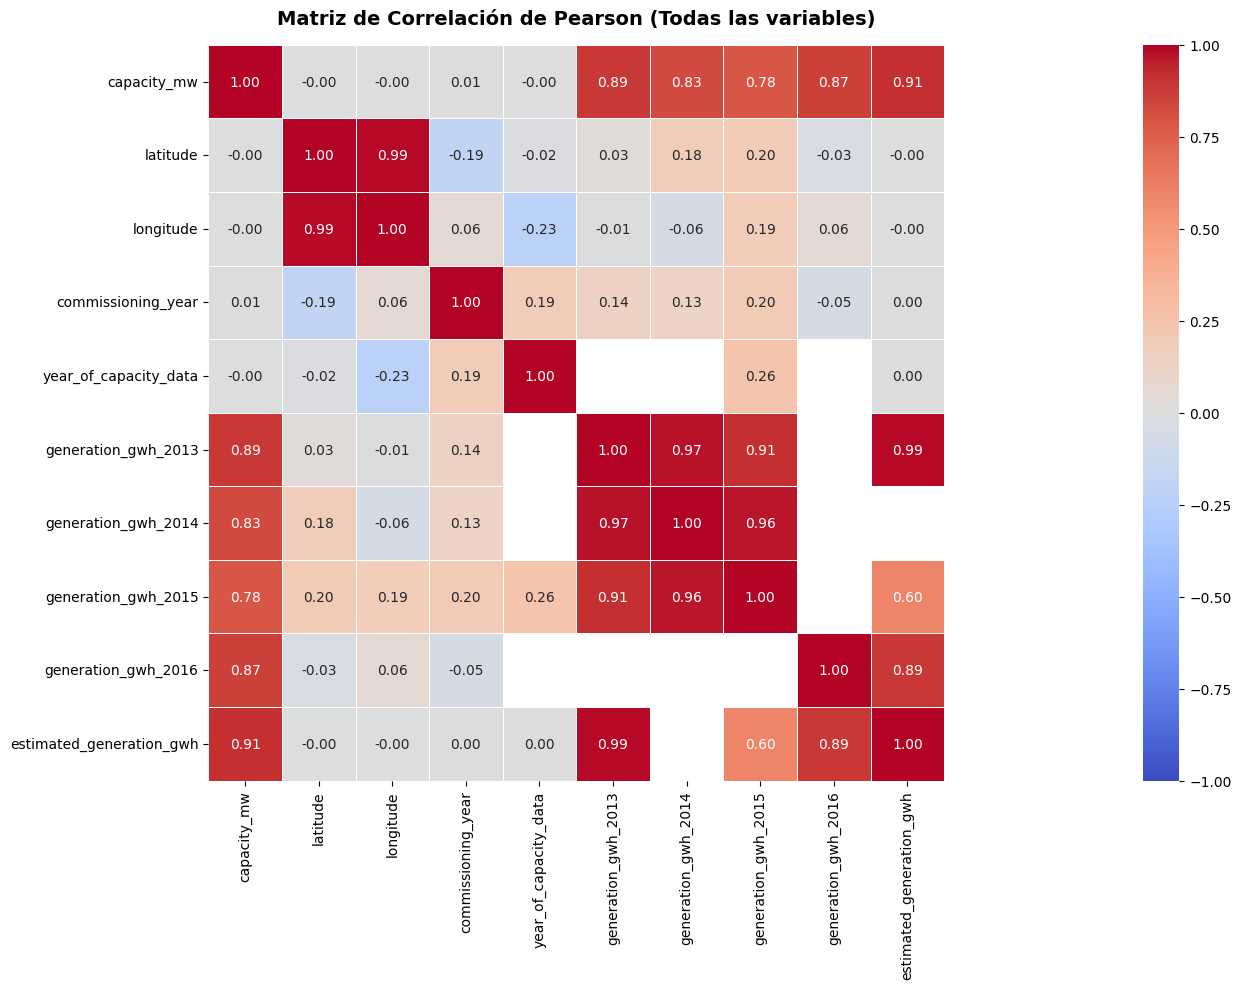

In [ ]:
# 1. Filtramos solo las columnas numéricas para evitar errores
variables_numericas = DATA.select_dtypes(include=['number', 'float', 'int'])

# 2. Calculamos la matriz de correlación de Pearson
matriz_corr = variables_numericas.corr()

# 3. Aumentamos un poco el tamaño de la figura por si tienes muchas columnas
plt.figure(figsize=(40, 10))

# 4. Graficamos el mapa de calor
# Tip: Si tienes demasiadas columnas y los números se superponen, cambia annot=True a annot=False
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)

plt.title('Matriz de Correlación de Pearson (Todas las variables)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Implementamos inicialmente una matriz de correlación, para entender mejor nuestro dataset, y que nos sirva de ayuda para eliminación de variables con poca correlación.

##3.1.- Eliminación de variable Country

Vamos a ir analizando variable por variable, detectando los valores que contienen y si necesitan ser tratadas o eliminadas.

Detectamos que tenemos dos variables iguales, COUNTRY y Country_long por lo podriamos tener informacion redundante. Como haremos regresion lineal, tendremos que pasar las variables a numeros y en caso de no eliminar una de las columnas tendremos dos veces los mismos datos, generando multicolinealidad entre las variables.

In [ ]:
# Vemos cuantos valores únicos tienen las variables Country y Country_long
cant_country = DATA['country'].nunique()
cant_country_long = DATA['country_long'].nunique()

print(f"Países únicos en 'country': {cant_country}")
print(f"Países únicos en 'country_long': {cant_country_long}")

Países únicos en 'country': 164
Países únicos en 'country_long': 164


Acá demostramos que existen la misma cantidad de paises y sus simbolos que se repiten y es un dato redundante para el Análisis posterior. Entonces siguiendo los Supuestos de Gauss-Markov y evitando una Multicolinealidad entre las variable, eliminaremos la columna "country".

In [ ]:
# Eliminamos la columna "Country"
DATA = DATA.drop(columns=['country'])
DATA.head()

,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,fuel4,...,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN


##3.2.- Eliminación variables de combustibles

Continuando con la exploracion de la Base de Datos, visualizamos que en las columnas fuel2, fuel3 y fuel4 se aprecian una alta proporción de valores faltantes, también demostrado en un previo análisis anterior.

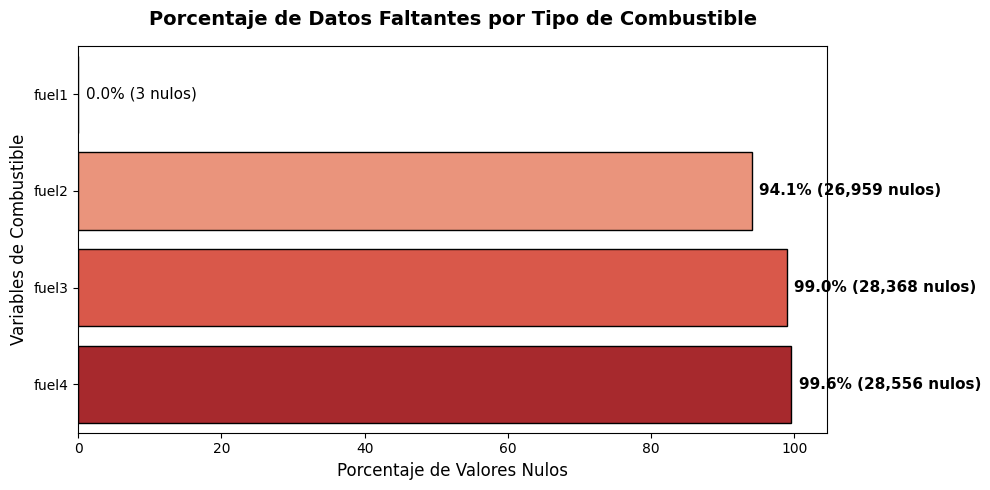

In [ ]:
# Graficamos los tipos de combustibles y los valores faltantes que hay en cada variable.
combustibles = ['fuel1', 'fuel2', 'fuel3', 'fuel4']
nulos_cantidad = DATA[combustibles].isnull().sum()
nulos_porcentaje = (DATA[combustibles].isnull().sum() / len(DATA)) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=nulos_porcentaje.values, y=nulos_porcentaje.index, hue=nulos_porcentaje.index, palette='Reds', edgecolor='black', legend=False)
plt.title('Porcentaje de Datos Faltantes por Tipo de Combustible', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje de Valores Nulos', fontsize=12)
plt.ylabel('Variables de Combustible', fontsize=12)

# Etiquetas numéricas precisas al final de cada barra
for i, bar in enumerate(ax.patches):
    width = bar.get_width()
    cantidad = nulos_cantidad.iloc[i]
    # Muestra el porcentaje y la cantidad absoluta entre paréntesis
    label_text = f'{width:.1f}% ({cantidad:,} nulos)' if width > 0 else '0% (Completo)'
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, label_text,
            va='center', ha='left', fontsize=11, fontweight='bold' if width > 50 else 'normal')

plt.tight_layout()
plt.show()

In [ ]:
# Procedemos a eliminar las variables "fuel2", "fuel3", "fuel4"
DATA = DATA.drop(columns=['fuel2', 'fuel3', 'fuel4'])
DATA.head()

,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,commissioning_year,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN


Se optó por eliminar las variables de combustibles secundarios (fuel2, fuel3, fuel4) dado que presentan una proporción mayor a 94% de ausencia de datos. Imputar estos valores introduciría un sesgo artificial masivo, mientras que eliminarlos permite centrar el modelo en el fuel1 (combustible primario), el cual está completo y es el principal determinante de la capacidad y generación de las plantas.

##3.3.- Eliminación de variables de reportes de generacion anual

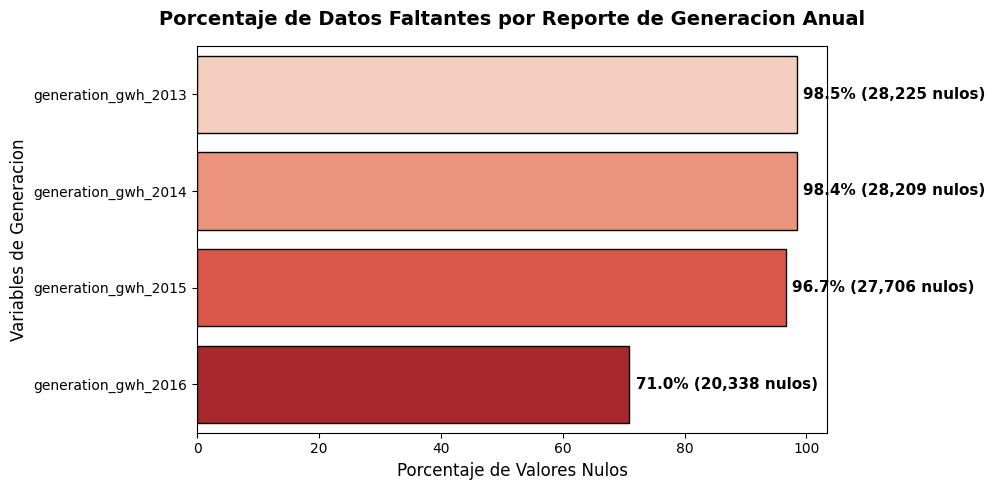

In [ ]:
# Graficamos los reportes anuales y los valores faltantes que hay en cada variable.
columnas_generacion = ['generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016']
nulos_cantidad_gen = DATA[columnas_generacion].isnull().sum()
nulos_porcentaje_gen = (DATA[columnas_generacion].isnull().sum() / len(DATA)) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=nulos_porcentaje_gen.values, y=nulos_porcentaje_gen.index, hue=nulos_porcentaje_gen.index, palette='Reds', edgecolor='black', legend=False)
plt.title('Porcentaje de Datos Faltantes por Reporte de Generacion Anual', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje de Valores Nulos', fontsize=12)
plt.ylabel('Variables de Generacion', fontsize=12)

# Etiquetas numéricas precisas al final de cada barra
for i, bar in enumerate(ax.patches):
    width = bar.get_width()
    cantidad = nulos_cantidad_gen.iloc[i]
    # Muestra el porcentaje y la cantidad absoluta entre paréntesis
    label_text = f'{width:.1f}% ({cantidad:,} nulos)' if width > 0 else '0% (Completo)'
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, label_text,
            va='center', ha='left', fontsize=11, fontweight='bold' if width > 50 else 'normal')

plt.tight_layout()
plt.show()

In [ ]:
# Procedemos a eliminar las variables 'generation_gwh_2013', 'generation_gwh_2014' y 'generation_gwh_2015'
DATA = DATA.drop(columns=['generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015'])
# Verificamos cómo queda la estructura del dataset
DATA.head()

,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,commissioning_year,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2016,estimated_generation_gwh
0,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN
1,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN
2,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN
3,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN
4,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN


Se procedió a la eliminación de las variables de generación histórica anual (generation_gwh_2013, generation_gwh_2014, generation_gwh_2015) manteniendo la variable generation_gwh_2016 ya que será la Target de nuestros modelos siguientes.

In [ ]:
# Verificamos nuevamente las columnas con datos faltantes para ver cuales más necesitamos eliminar
nulos_porcentaje = (DATA.isnull().sum() / len(DATA)) * 100
print(nulos_porcentaje[nulos_porcentaje > 0])

name                         0.069774
fuel1                        0.010466
commissioning_year          47.837008
owner                       36.879012
geolocation_source           1.468741
year_of_capacity_data       43.674993
generation_gwh_2016         70.953112
estimated_generation_gwh     3.935250
dtype: float64


##3.4.- Eliminación de variables que no aportan valor a nuestro análisis

In [ ]:
# Procedemos a eliminar las variables
DATA = DATA.drop(columns=['name', 'commissioning_year', 'owner',
                          'geolocation_source', 'year_of_capacity_data',
                          'estimated_generation_gwh', 'gppd_idnr', 'latitude',
                          'longitude', 'source', 'url'])

# Verificamos cómo queda la estructura del dataset
DATA.head()

,country_long,capacity_mw,fuel1,generation_gwh_2016
0,Afghanistan,33.00,Hydro,NaN
1,Afghanistan,66.00,Hydro,NaN
2,Afghanistan,100.00,Hydro,NaN
3,Afghanistan,11.55,Hydro,NaN
4,Afghanistan,42.00,Gas,NaN


Eliminamos las variables que no aportarían valor a los modelos de regresión, además incluimos en la eliminación a la variable "estimated_generation_gwh", ya que la misma fue generada por el creador del dataset, y podría influir en nuestro análsis.

## 3.5.- Creación de Boxplot

Se van a graficar 2 variables numéricas:
['capacity_mw', 'generation_gwh_2016']



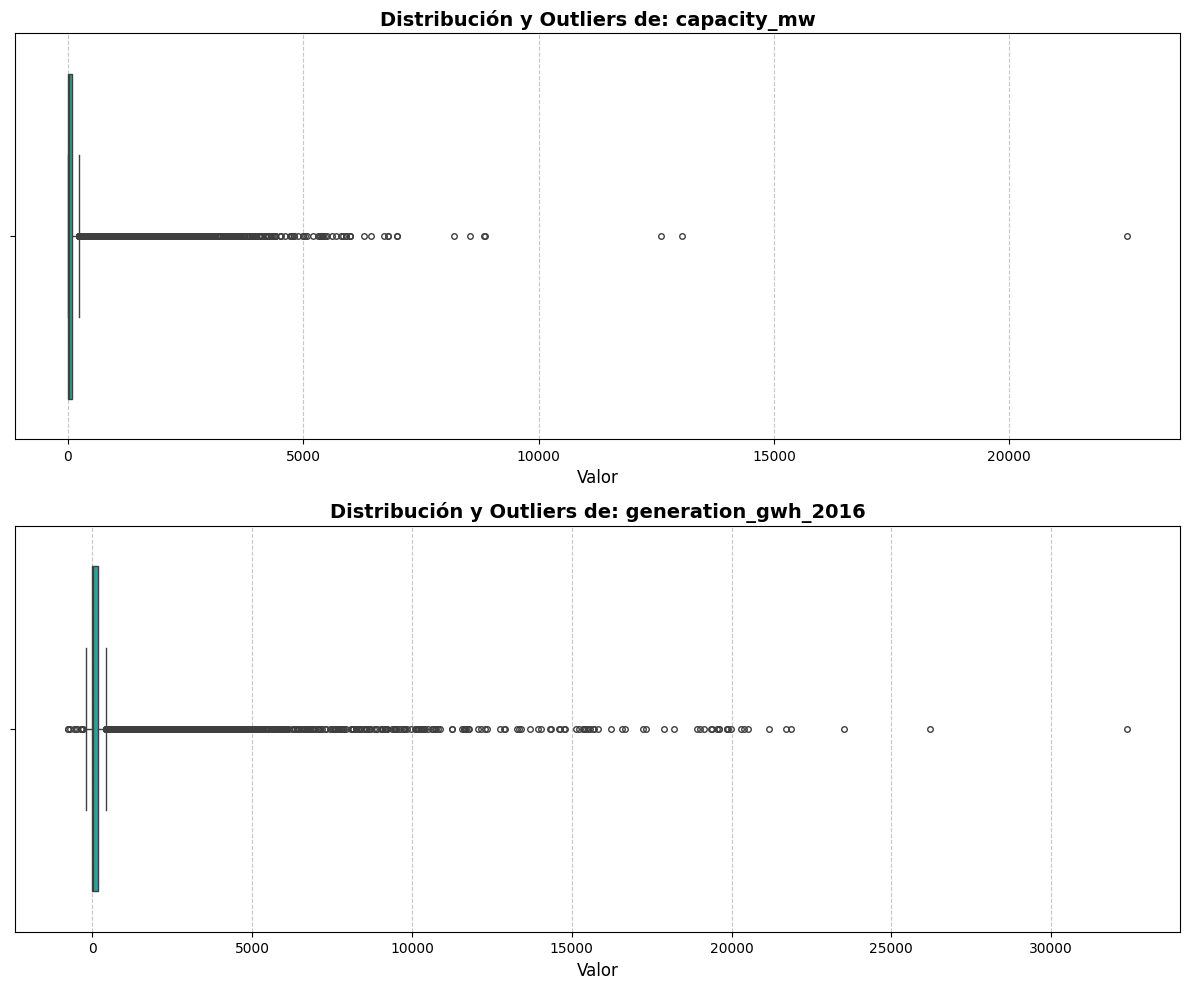

In [ ]:
# Representamos las variables numericas en Boxplot para detectar outliers
columnas_numericas = DATA.select_dtypes(include=[np.number]).columns.tolist()

print(f"Se van a graficar {len(columnas_numericas)} variables numéricas:\n{columnas_numericas}\n")

plt.figure(figsize=(12, 5 * len(columnas_numericas)))

# Iteramos por cada variable numérica
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(len(columnas_numericas), 1, i)

    # Generamos el boxplot horizontal con Seaborn
    sns.boxplot(x=DATA[col], color='lightseagreen', fliersize=4)
    plt.title(f'Distribución y Outliers de: {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Valor', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Al visualizar los Boxplots, notamos la presencia de outliers en las variables "capacity_mw" y generation_gwh_2016. Presentan una asimetria positiva (sesgo a la derecha) con muchos valores atipicos, debido a la alta concentración en la escala de infraestructura energetica.

In [ ]:
# Contar outliers usando el método del Rango Intercuartílico (IQR)
print("--- CANTIDAD DE OUTLIERS POR VARIABLE ---")

for col in columnas_numericas:
    # Calculamos el primer y tercer cuartil
    Q1 = DATA[col].quantile(0.25)
    Q3 = DATA[col].quantile(0.75)

    # Calculamos el Rango Intercuartílico
    IQR = Q3 - Q1

    # Definimos los límites
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Contamos cuántos valores están fuera de los límites
    outliers = DATA[(DATA[col] < limite_inf) | (DATA[col] > limite_sup)][col]
    cantidad = len(outliers)
    porcentaje = (cantidad / len(DATA)) * 100

    if cantidad > 0:
        print(f"Variable '{col}': {cantidad} outliers ({porcentaje:.2f}% de los datos)")
    else:
        print(f"Variable '{col}': Sin outliers detectados.")
print("-" * 40)

--- CANTIDAD DE OUTLIERS POR VARIABLE ---
Variable 'capacity_mw': 4617 outliers (16.11% de los datos)
Variable 'generation_gwh_2016': 1276 outliers (4.45% de los datos)
----------------------------------------


Al analizar la distribución de los datos, detectamos una cantidad importante de outliers, especialmente en capacity_mw (16.11%) y generation_gwh_2016 (4.45%). Por este motivo, decidimos aplicarles una transformación logarítmica para normalizar la distribución y reducir el impacto de estos valores extremos.

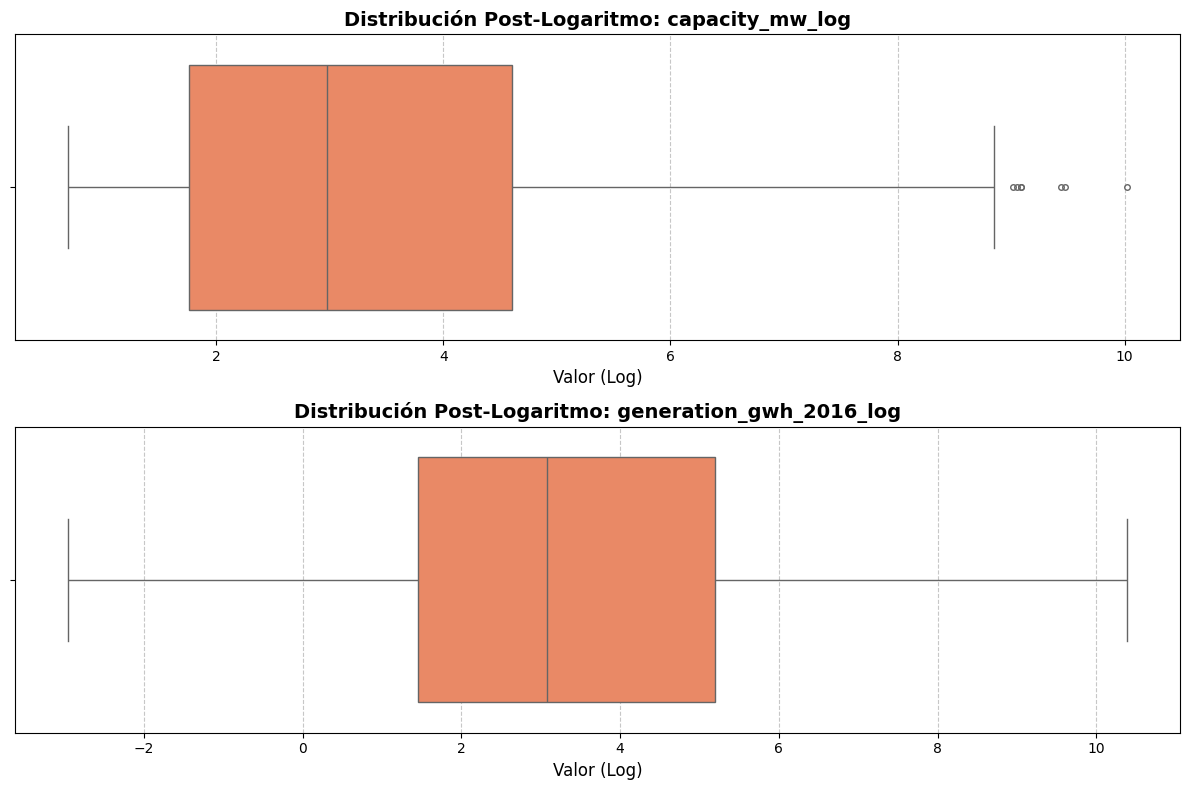

In [ ]:
warnings.filterwarnings('ignore', category=RuntimeWarning) # limpiamos la leyenda que aparecia debajo del grafico

# Definimos las variables que vamos a aplicar el logaritmo
columnas_a_transformar = ['capacity_mw', 'generation_gwh_2016']

# Aplicamos np.log1p iterando sobre la lista y creamos columnas nuevas con el sufijo '_log'
for col in columnas_a_transformar:
    if col in DATA.columns:
        DATA[col + '_log'] = np.log1p(DATA[col])

# Nos aseguramos de graficar solo las versiones logarítmicas nuevas
columnas_log = [col + '_log' for col in columnas_a_transformar if col + '_log' in DATA.columns]

# Generamos los Boxplots
plt.figure(figsize=(12, 4 * len(columnas_log)))

for i, col_log in enumerate(columnas_log, 1):
    plt.subplot(len(columnas_log), 1, i)
    sns.boxplot(x=DATA[col_log], color='coral', fliersize=4)
    plt.title(f'Distribución Post-Logaritmo: {col_log}', fontsize=14, fontweight='bold')
    plt.xlabel('Valor (Log)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Con la aplicación del metodo logaritmico (np.log1p), logramos balancear las variables, volviendolas más simetricas y legibles. La distancia entre las plantas pequeñas y las gigantes se estabilizó. Los pocos valores atipicos que quedaron fuera de la caja, no tendrán la misma fuerza que antes para distorcionar la recta de la Regresión.

##3.6.- Análisis descriptivo

In [ ]:
# Realizamos un Analisis Descriptivo para ver como quedaron los datos
print("--- ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES DEL MODELO ---")
display(DATA.describe())

--- ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES DEL MODELO ---


,capacity_mw,generation_gwh_2016,capacity_mw_log,generation_gwh_2016_log
count,28664.000000,8326.000000,28664.000000,8276.000000
mean,186.097600,532.668481,3.297860,3.399605
std,523.027253,1935.490760,1.915854,2.447629
min,1.000000,-768.620000,0.693147,-2.956512
25%,4.795850,3.197500,1.757142,1.453193
50%,18.640000,20.354000,2.977568,3.084819
75%,99.200000,176.508999,4.607168,5.198182
max,22500.000000,32377.477000,10.021315,10.385249


In [ ]:
# Elimina filas con nulos
DATA = DATA.dropna(subset=['generation_gwh_2016'])

# Filtra quedándose solo con las plantas que generaron MÁS de 0
DATA = DATA[DATA['generation_gwh_2016'] > 0]
DATA.reset_index(drop=True, inplace=True)

Eliminamos las filas nulas porque generation_gwh_2016 es la variable que queremos predecir (nuestro target). Si ese dato falta, el modelo no tiene de dónde aprender. Por otro lado, filtramos los valores menores a cero porque representan plantas que estuvieron apagadas o inactivas, lo cual solo le sumaría ruido al entrenamiento.

In [ ]:
# Informacion actual del Dataset
print("--- Información General ---")
DATA.info()

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7836 entries, 0 to 7835
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country_long             7836 non-null   object 
 1   capacity_mw              7836 non-null   float64
 2   fuel1                    7836 non-null   object 
 3   generation_gwh_2016      7836 non-null   float64
 4   capacity_mw_log          7836 non-null   float64
 5   generation_gwh_2016_log  7836 non-null   float64
dtypes: float64(4), object(2)
memory usage: 367.4+ KB


##3.7.- Generación de Dummies a la variable Fuel1

In [ ]:
# Observamos la variable fuel1
DATA["fuel1"].value_counts()

,count
fuel1,
Solar,1704
Hydro,1556
Oil,1239
Gas,1044
Wind,991
Waste,594
Coal,459
Geothermal,69
Nuclear,68


Duplicar la columna fuel1, para usarla para el muestreo.

In [ ]:
# 1. Hacemos una copia de seguridad de la columna antes de que get_dummies la elimine
DATA['combustible_para_muestreo'] = DATA['fuel1']

In [ ]:
# Usamos drop_first=True. Si hay 5 combustibles, creará 4 columnas.
DATA = pd.get_dummies(DATA, columns=['fuel1'], drop_first=True, dtype=int)

Generamos las variables dummies a "fuel1" para que quede el Dataset en mejor estado y trabajar el modelo con dichas variables.

##3.8.- Generación de Dummies de los países

In [ ]:
# Observamos la variable country_long
DATA["country_long"].value_counts()

,count
country_long,
United States of America,7501
Vietnam,156
Germany,76
Guatemala,55
Kenya,21
Netherlands,15
Morocco,6
South Africa,3
Austria,2


In [ ]:
# Usamos drop_first=True para evitar la trampa de la multicolinealidad
DATA = pd.get_dummies(DATA, columns=['country_long'], drop_first=True, dtype=int)

# Veamos cómo explotó la cantidad de columnas
print(f"Nueva cantidad total de columnas: {DATA.shape[1]}")

Nueva cantidad total de columnas: 27


In [ ]:
# Chequeamos el Dataset
DATA.head()

,capacity_mw,generation_gwh_2016,capacity_mw_log,generation_gwh_2016_log,combustible_para_muestreo,fuel1_Coal,fuel1_Cogeneration,fuel1_Gas,fuel1_Geothermal,fuel1_Hydro,...,fuel1_Wind,country_long_Egypt,country_long_Germany,country_long_Guatemala,country_long_Kenya,country_long_Morocco,country_long_Netherlands,country_long_South Africa,country_long_United States of America,country_long_Vietnam
0,289.0,118.791,5.669881,4.785749,Hydro,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,500.0,128.530,6.216606,4.863913,Hydro,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2250.0,133.000,7.719130,4.897840,Gas,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3,1480.0,10505.870,7.300473,9.259785,Nuclear,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,717.0,2684.819,6.576470,7.895741,Coal,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Chequeamos la info
DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7836 entries, 0 to 7835
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   capacity_mw                            7836 non-null   float64
 1   generation_gwh_2016                    7836 non-null   float64
 2   capacity_mw_log                        7836 non-null   float64
 3   generation_gwh_2016_log                7836 non-null   float64
 4   combustible_para_muestreo              7836 non-null   object 
 5   fuel1_Coal                             7836 non-null   int64  
 6   fuel1_Cogeneration                     7836 non-null   int64  
 7   fuel1_Gas                              7836 non-null   int64  
 8   fuel1_Geothermal                       7836 non-null   int64  
 9   fuel1_Hydro                            7836 non-null   int64  
 10  fuel1_Nuclear                          7836 non-null   int64  
 11  fuel

Con el propósito de adecuar el conjunto de datos para la posterior alimentación de algoritmos de Machine Learning, se procedió a transformar la variable categórica country_long en dummies, mediante un esquema de codificación One-Hot (One-Hot Encoding).

In [ ]:
# Borrar las columnas originales
DATA = DATA.drop(columns=['capacity_mw', 'generation_gwh_2016'])
DATA.head()

,capacity_mw_log,generation_gwh_2016_log,combustible_para_muestreo,fuel1_Coal,fuel1_Cogeneration,fuel1_Gas,fuel1_Geothermal,fuel1_Hydro,fuel1_Nuclear,fuel1_Oil,...,fuel1_Wind,country_long_Egypt,country_long_Germany,country_long_Guatemala,country_long_Kenya,country_long_Morocco,country_long_Netherlands,country_long_South Africa,country_long_United States of America,country_long_Vietnam
0,5.669881,4.785749,Hydro,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,6.216606,4.863913,Hydro,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7.719130,4.897840,Gas,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,7.300473,9.259785,Nuclear,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
4,6.576470,7.895741,Coal,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


Se eliminaron las variables originales capacity_mw y generation_gwh_2016 porque su variabilidad e información estructural ya fueron completamente absorbidas y normalizadas mediante las transformaciones logarítmicas.

Mantenerlas en la matriz de diseño no agregaría ningún valor predictivo nuevo y, por el contrario, induciría a problemas de redundancia e inestabilidad (multicolinealidad) en los algoritmos de estimación y modelos predictivos.

##3.9.- Graficamos el Análisis Descriptivo

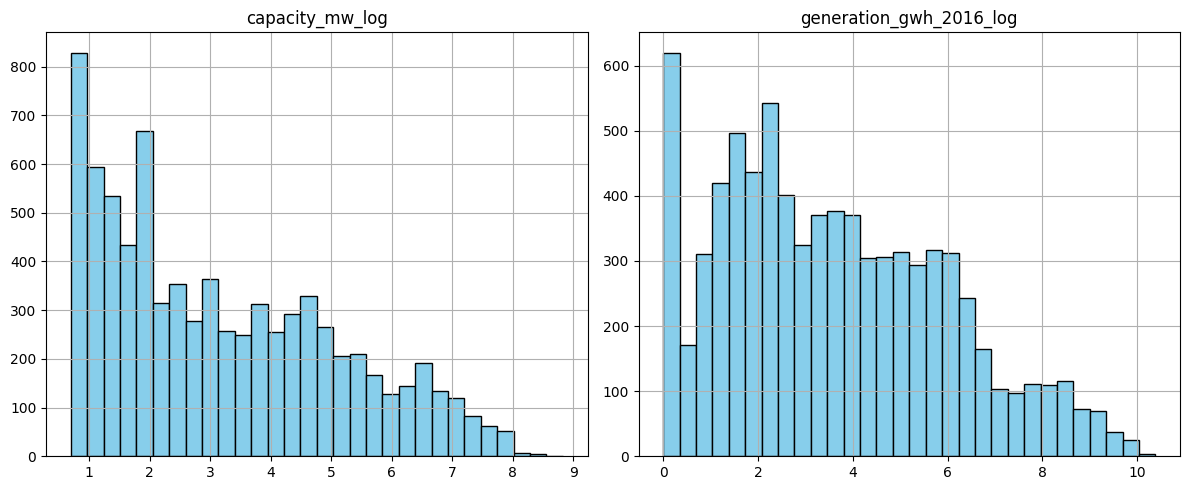

In [ ]:
# Seleccionamos únicamente las variables continuas numéricas del modelo
variables_continuas = ['capacity_mw_log', 'generation_gwh_2016_log']

# Graficamos los histogramas en una grilla cómoda
DATA[variables_continuas].hist(figsize=(12, 5), bins=30, edgecolor='black', color='skyblue')

plt.tight_layout()
plt.show()

A partir del análisis gráfico inicial, se observaba que las variables mostraban un sesgo a la derecha (asimetría positiva), concentrando la mayor parte de las observaciones en los valores bajos de la izquierda y extendiendo una larga cola hacia la derecha. Sin embargo, tal como se evidencia en estos nuevos histogramas, la aplicación de la transformación logarítmica logró corregir dicha asimetría, distribuyendo las frecuencias de manera mucho más equilibrada y homogénea a lo largo de la escala para estabilizar la varianza.


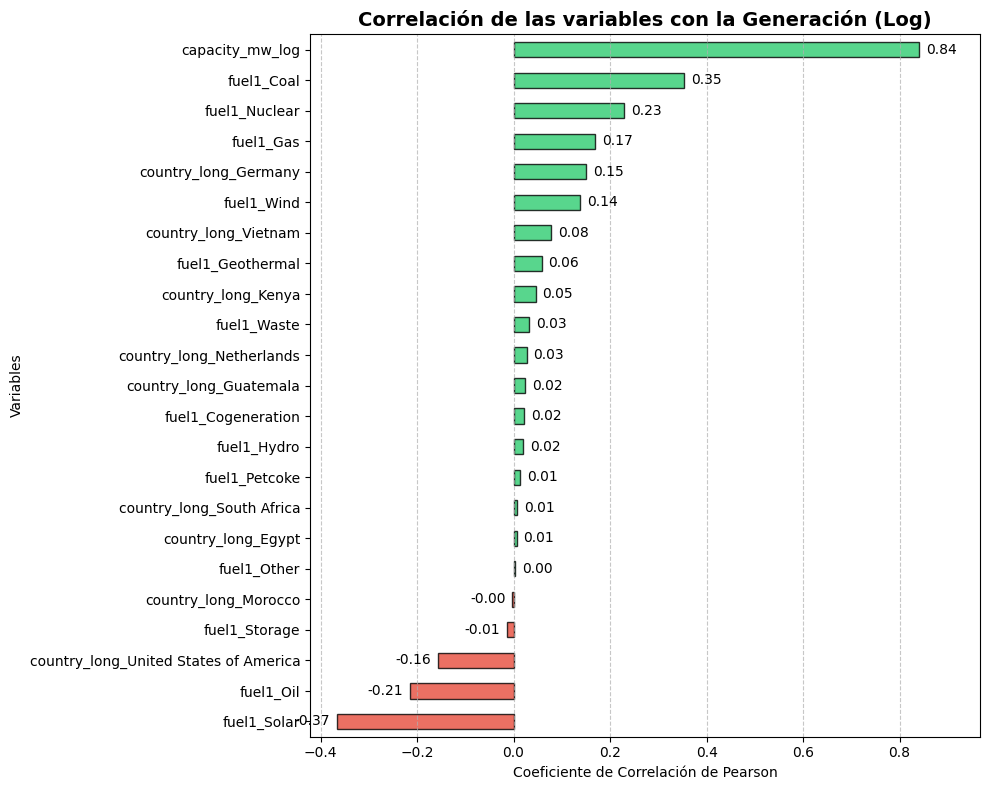

In [ ]:
# 1. Calculamos la correlación
correlaciones_capacidad = DATA.select_dtypes(include='number').corr()['generation_gwh_2016_log'].drop('generation_gwh_2016_log')

# 2. Ordenamos para que el gráfico tenga sentido
correlaciones_capacidad = correlaciones_capacidad.sort_values()

# 3. Graficamos
plt.figure(figsize=(10, 8))
colores = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlaciones_capacidad]

# Guardamos el plot en 'ax'
ax = correlaciones_capacidad.plot(kind='barh', color=colores, edgecolor='black', alpha=0.8)

# Agregamos los valores en formato decimal (2 decimales)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5)

# Ampliamos un poco los márgenes en X para que no se corten los números
plt.xlim(correlaciones_capacidad.min() * 1.15, correlaciones_capacidad.max() * 1.15)

# Título actualizado a 'Generación'
plt.title('Correlación de las variables con la Generación (Log)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El gráfico destaca una alta correlación positiva (0.84) entre capacity_mw_log y generation_gwh_2016_log. Esto indica una relación directa y lógica: para que una planta pueda inyectar grandes volúmenes de energía a la red, necesita contar con una estructura física proporcionalmente gigante que respalde dicha generación.

#4.- Muestreo e Inferencia (Unidad 1)

#### 4.1.- Muestreo simple

In [ ]:
# Establecemos la semilla de los modelos:
semilla = 7

In [ ]:
# Generamos una muestra de 750 y seteamos una semilla para tener guardado el registro de la muestra
muestra = DATA.sample(n=750, random_state = semilla)

# Establecemos la variable objetivo
variable_objetivo = 'generation_gwh_2016_log'

# Calculamos media y varianza de la población total
media_pob = DATA[variable_objetivo].mean()
var_pob = DATA[variable_objetivo].var()

# Calculamos media y varianza de la muestra (n=750)
media_mue = muestra[variable_objetivo].mean()
var_mue = muestra[variable_objetivo].var()

# Imprimimos los resultados
print("--- VALIDACIÓN DE REPRESENTATIVIDAD ---")
print(f"Variable analizada: {variable_objetivo}\n")
print(f"Media Poblacional: {media_pob:.4f}  |  Media Muestral: {media_mue:.4f}")
print(f"Varianza Poblacional: {var_pob:.4f} |  Varianza Muestral: {var_mue:.4f}")

# Diferencia porcentual
diff_media = abs((media_pob - media_mue) / media_pob) * 100
print(f"\nDiferencia en la media: {diff_media:.2f}%")

--- VALIDACIÓN DE REPRESENTATIVIDAD ---
Variable analizada: generation_gwh_2016_log

Media Poblacional: 3.5958  |  Media Muestral: 3.5874
Varianza Poblacional: 5.5969 |  Varianza Muestral: 5.4441

Diferencia en la media: 0.23%


Utilizando una muestra aleatoria de 750 observaciones, observamos una precisión excelente respecto a las propiedades de la población total. Con una diferencia de solo 0.23% en el valor de la media, confirmamos que la muestra no presenta sesgos de selección y es completamente representativa para realizar inferencias estadísticas válidas.

#### 4.2.- Muestreo Estratificado:

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Usamos la columna de backup para estratificar perfectamente
muestra2, resto = train_test_split(
    DATA,
    train_size=750,
    stratify=DATA['combustible_para_muestreo'],
    random_state=semilla
)

# 2. Eliminamos la columna de backup de nuestra muestra porque ya cumplió su función
muestra2 = muestra2.drop(columns=['combustible_para_muestreo'])

print(f"Muestra estratificada generada con {len(muestra)} registros y lista para el modelo.")

Muestra estratificada generada con 750 registros y lista para el modelo.


In [ ]:
import pandas as pd

print("=== VALIDACIÓN DE REPRESENTATIVIDAD (Diferencia Absoluta) ===\n")

df_poblacion = DATA.drop(columns=['combustible_para_muestreo'], errors='ignore')
resultados = []

# Iteramos por todas las columnas
for col in df_poblacion.columns:
    media_pob = df_poblacion[col].mean()
    media_mue = muestra2[col].mean()

    # EL CAMBIO CLAVE: Calculamos la diferencia absoluta en puntos porcentuales
    diff_abs = abs(media_pob - media_mue) * 100

    resultados.append({'Variable': col, 'Diferencia Absoluta (%)': diff_abs})

# Armamos la tabla
df_diferencias = pd.DataFrame(resultados).sort_values(by='Diferencia Absoluta (%)', ascending=False)

print("(Diferencias menores al 5% son excelentes)\n")
print(df_diferencias.to_string(index=False))

=== VALIDACIÓN DE REPRESENTATIVIDAD (Diferencia Absoluta) ===

(Diferencias menores al 5% son excelentes)

                             Variable  Diferencia Absoluta (%)
                      capacity_mw_log                 3.767316
              generation_gwh_2016_log                 2.091366
country_long_United States of America                 1.608474
               country_long_Guatemala                 0.701889
                 country_long_Vietnam                 0.657478
                 country_long_Germany                 0.303216
            country_long_South Africa                 0.095048
                 country_long_Morocco                 0.076570
             country_long_Netherlands                 0.075242
                        fuel1_Nuclear                 0.067790
                        fuel1_Storage                 0.063808
                   fuel1_Cogeneration                 0.059418
                            fuel1_Oil                 0.055028
           

Nos quedamos con el muestreo aleatorio simple porque es el camino más directo y eficiente. Nos asegura una precisión casi perfecta (apenas un 0,23% de desvío) exactamente en la variable que nos importa predecir. No tiene sentido sumar la complejidad de estratificar los datos cuando un método más sencillo ya nos garantiza una muestra sólida.

#5.- Modelado Estadístico Clásico (Unidades 3, 4 y 5)

##5.1.- Regresión sobre el muestreo:

In [ ]:
# Definimos la variable objetivo (Target) y las predictores
variable_Y = 'generation_gwh_2016_log'

# Seleccionamos solo los predictores continuos transformados y las dummies de combustible
columnas_X = DATA.select_dtypes(include=['number']).drop(columns=[variable_Y]).columns.tolist()

# ==========================================
# MODELO 1: MUESTRA (n=750)
# ==========================================
X_muestra = muestra[columnas_X]
Y_muestra = muestra[variable_Y]

# Agregamos la Constante (el intercepto Beta 0)
X_muestra = sm.add_constant(X_muestra)

# Ajustamos el Modelo Mínimos Cuadrados Ordinarios
modelo_muestra = sm.OLS(Y_muestra, X_muestra).fit()

print("=================== RESULTADOS MUESTRA (n=750) ===================")
print(modelo_muestra.summary())

=================== RESULTADOS MUESTRA (n=750) ===================
                               OLS Regression Results                              
Dep. Variable:     generation_gwh_2016_log   R-squared:                       0.808
Model:                                 OLS   Adj. R-squared:                  0.804
Method:                      Least Squares   F-statistic:                     181.6
Date:                     Sat, 06 Jun 2026   Prob (F-statistic):          6.57e-249
Time:                             17:09:36   Log-Likelihood:                -1079.6
No. Observations:                      750   AIC:                             2195.
Df Residuals:                          732   BIC:                             2278.
Df Model:                               17                                         
Covariance Type:                 nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025

####**Resultados del Modelo**

* **Ajuste general:** El modelo explica el **80.8%** de la generación de energía. Es un porcentaje altísimo y nos deja muy conformes.

**¿Qué variables importan más?**

* **Capacidad de la planta:** Sigue siendo la variable que mejor predice. Nos dio que, por cada 1% que ampliamos la capacidad de una planta, su generación real sube un **1.06%**.

* **Combustibles:** El Gas, el Oil y la energía Solar dieron coeficientes negativos. Esto tiene sentido: a igual tamaño, generan menos energía anual que otras tecnologías porque dependen del clima (solar) o se prenden solo para cubrir picos de demanda (fósiles).

* **Países:** Casi ningún país dio significativo. Básicamente, si ya sabemos el tamaño de la planta y qué combustible usa, saber en qué país está no suma información relevante para la predicción.

**Diagnóstico y problemas técnicos**

* **Residuos:** El indicador Durbin-Watson dio **2.1**. Al estar tan pegado a 2, nos deja tranquilos de que no hay problemas de autocorrelación.

* **Normalidad:** Los residuos no tienen una distribución perfectamente normal (según la prueba de Jarque-Bera). Pero como tenemos una muestra grande de 750 casos, por el Teorema del Límite Central, los resultados siguen siendo estadísticamente válidos.

* **Advertencias esperadas:** Nos saltaron valores nulos en países como Sudáfrica o Países Bajos simplemente porque en esta muestra de 750 al azar no cayó ninguna planta de ahí. Además, tiró un aviso de multicolinealidad, algo totalmente normal porque metimos muchísimas variables *dummy* todas juntas.

##5.2.- Regresión sobre toda la base

In [ ]:
# ==========================================
# MODELO 2: POBLACIÓN TOTAL (Base Completa)
# ==========================================
X_total = DATA[columnas_X]
Y_total = DATA[variable_Y]

X_total = sm.add_constant(X_total)
modelo_total = sm.OLS(Y_total, X_total).fit()

# ==========================================
# IMPRIMIR RESULTADOS PARA COMPARAR
# ==========================================

print("=================== RESULTADOS POBLACIÓN TOTAL ===================")
print(modelo_total.summary())

=================== RESULTADOS POBLACIÓN TOTAL ===================
                               OLS Regression Results                              
Dep. Variable:     generation_gwh_2016_log   R-squared:                       0.816
Model:                                 OLS   Adj. R-squared:                  0.815
Method:                      Least Squares   F-statistic:                     1503.
Date:                     Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                             17:09:37   Log-Likelihood:                -11241.
No. Observations:                     7836   AIC:                         2.253e+04
Df Residuals:                         7812   BIC:                         2.270e+04
Df Model:                               23                                         
Covariance Type:                 nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025

#### **Resultados con el Dataset Completo (7836 registros)**

* **Ajuste general (R-cuadrado):** El modelo explica casi el **82%** de la energía generada. Básicamente, con saber el tamaño, el tipo de combustible y el país de la planta, logramos una predicción excelente.

**¿Qué variables mueven la aguja?**

* **Tamaño de la planta (`capacity_mw_log`):** Sigue siendo el factor principal. La relación es casi directa: si la capacidad aumenta un 1%, la generación anual real sube un **1.04%**.

* **Tipo de combustible:** Ahora con todos los datos vemos qué tecnologías rinden más. Las plantas **Nucleares y de Residuos** lideran porque operan las 24 horas. Por el contrario, la **Solar, Eólica, Oil y Gas** generan menos a igual tamaño (ya sea porque dependen del clima o porque solo se prenden para cubrir picos de consumo).

* **El factor país:** A diferencia de la muestra más chica, acá comprobamos que la ubicación es clave. Estar en países como Alemania, EE.UU., Vietnam o Guatemala tiene un impacto positivo; a igual tamaño y combustible, logran generar más energía (seguramente por tener mejores redes eléctricas o demanda constante).

**Confiabilidad del modelo**

* **Residuos limpios:** El indicador Durbin-Watson dio **1.9**. Al estar tan cerca de 2, nos confirma que no hay ruido ni problemas raros arrastrándose en los datos.

* **Normalidad:** La prueba de Jarque-Bera marca que los errores no hacen una campana de Gauss perfecta, pero no nos afecta en nada. Como tenemos casi 8000 filas, las reglas de la estadística nos avalan y nos aseguran que estas conclusiones son totalmente sólidas para la toma de decisiones.

## 5.3.- Regresión optimizada

In [ ]:
# ==========================================
# MODELO 3: POBLACIÓN TOTAL (Optimizado - Backward)
# ==========================================

# Arrancamos con la lista de todas las columnas del modelo original
columnas_actuales = list(X_total.columns)

print("Iniciando limpieza de variables paso a paso...\n")

while True:
    # 1. Armamos el set con las columnas que van quedando en esta iteración
    X_tmp = X_total[columnas_actuales]

    # 2. Entrenamos el modelo temporalmente
    modelo_tmp = sm.OLS(Y_total, X_tmp).fit()

    # 3. Buscamos el p-valor más alto (ignorando la 'const' para no borrarla)
    p_valores = modelo_tmp.pvalues.drop('const', errors='ignore')
    max_p_valor = p_valores.max()

    # 4. Verificamos si la peor variable supera nuestro límite de 0.05
    if max_p_valor > 0.05:
        # Identificamos cuál es y la sacamos de la lista
        variable_a_eliminar = p_valores.idxmax()
        columnas_actuales.remove(variable_a_eliminar)
        print(f"Eliminando: {variable_a_eliminar} (p-valor: {max_p_valor:.4f})")
    else:
        # Si el peor p-valor ya es menor a 0.05, el modelo está limpio y cortamos el ciclo
        print("\n¡Optimización completada! Todas las variables restantes son estadísticamente significativas.")
        break

# ==========================================
# IMPRIMIR RESULTADOS LIMPIOS
# ==========================================
X_total_optimizado = X_total[columnas_actuales]
modelo_total_optimizado = sm.OLS(Y_total, X_total_optimizado).fit()

print("\n=================== RESULTADOS POBLACIÓN TOTAL (OPTIMIZADO) ===================")
print(modelo_total_optimizado.summary())

Iniciando limpieza de variables paso a paso...

Eliminando: fuel1_Petcoke (p-valor: 0.8873)
Eliminando: fuel1_Coal (p-valor: 0.6838)
Eliminando: fuel1_Other (p-valor: 0.5130)
Eliminando: country_long_Egypt (p-valor: 0.4084)
Eliminando: fuel1_Cogeneration (p-valor: 0.2818)
Eliminando: fuel1_Hydro (p-valor: 0.1658)
Eliminando: fuel1_Storage (p-valor: 0.0600)

¡Optimización completada! Todas las variables restantes son estadísticamente significativas.

=================== RESULTADOS POBLACIÓN TOTAL (OPTIMIZADO) ===================
                               OLS Regression Results                              
Dep. Variable:     generation_gwh_2016_log   R-squared:                       0.815
Model:                                 OLS   Adj. R-squared:                  0.815
Method:                      Least Squares   F-statistic:                     2160.
Date:                     Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                             17:09:37   L

Al evaluar nuestra primera regresión, notamos que había varias variables (como fuel1_Coal, fuel1_Hydro o country_long_Egypt) que no eran estadísticamente significativas. Para resolver esto sin romper la matriz de datos, aplicamos una eliminación de variables, retirando paso a paso las 7 variables que no aportaban valor.

Para decidir con qué modelo quedarnos, nos basamos en el principio estadístico de parsimonia, el cual indica que si dos modelos tienen un poder predictivo similar, siempre es preferible el más simple.

Al comparar los resultados, vimos que nuestro modelo optimizado mantiene un R-cuadrado excelente de 0.815


#6.- Machine Learning y Validación (Unidad 6)

In [ ]:
# Definimos la función una sola vez para usarla en todos los modelos
def calcular_metricas(y_real, y_pred, nombre_modelo, nombre_set):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    print(f"--- {nombre_modelo} ({nombre_set}) ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")

##6.1.- División de Datos (Train / Test Split)

####Para la parte de regresión fuimos muy estrictos a la hora de eliminar variables para tener un modelo limpio y poder entender qué impactaba y qué no. Pero al pasar a Machine Learning cambiamos la estrategia. Dejamos todas las variables originales, ya que estos algoritmos buscan predecir mejor y, a mayor cantidad de datos cruzados, tienen mayor posibilidades de encontrar patrones. De esta forma el modelo aprendió mejor y obtuvimos métricas superiores.

In [ ]:
# Definimos la variable objetivo correcta (Target) para predecir capacidad
y = DATA['generation_gwh_2016_log']

# Seleccionamos solo los predictores continuos transformados y las dummies de combustible
columnas_predictoras = [
    'capacity_mw_log',
    'fuel1_Coal', 'fuel1_Cogeneration', 'fuel1_Gas', 'fuel1_Geothermal',
    'fuel1_Hydro', 'fuel1_Nuclear', 'fuel1_Oil', 'fuel1_Other',
    'fuel1_Petcoke', 'fuel1_Solar', 'fuel1_Waste', 'fuel1_Wind',
    'country_long_Egypt', 'country_long_Germany', 'country_long_Guatemala',
    'country_long_Kenya', 'country_long_Morocco', 'country_long_Netherlands',
    'country_long_South Africa', 'country_long_United States of America', 'country_long_Vietnam'
]
X = DATA[columnas_predictoras]

# Dividimos los datos (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=semilla)


# Verificamos de las dimensiones resultantes
print("=== ESTRUCTURA DE PARTICIONAMIENTO ===")
print(f"Tamaño del set de Entrenamiento (X_train): {X_train.shape[0]} filas | {X_train.shape[1]} variables")
print(f"Tamaño del set de Prueba (X_test):        {X_test.shape[0]} filas | {X_test.shape[1]} variables")

=== ESTRUCTURA DE PARTICIONAMIENTO ===
Tamaño del set de Entrenamiento (X_train): 6268 filas | 22 variables
Tamaño del set de Prueba (X_test):        1568 filas | 22 variables


Primero, separamos la base total. Usamos 80% para entrenar y 20% para probar.

El resultado nos muestra que tenemos 6268 filas dedicadas para que el algoritmo aprenda(Train), mientras que 1568 filas quedan guardadas para evaluar que tan bien predice con datos nuevos(Test).

##6.2.- Entrenamiento de los Algoritmos

#### 6.2.1.- Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

## 6.2.1.- Entrenamiento y Evaluación: Random Forest

# 1. Instanciamos
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=semilla)

# 2. Entrenamos
rf_model.fit(X_train, y_train)

# 3. Predecimos
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

# 4. Evaluamos
print("Resultados Random Forest:")
calcular_metricas(y_train, rf_pred_train, "Random Forest", "TRAIN")
calcular_metricas(y_test, rf_pred_test, "Random Forest", "TEST")

# Mostrar la estructura del Random Forest
rf_model

Resultados Random Forest:
--- Random Forest (TRAIN) ---
MAE:  0.6705
MSE:  0.9574
RMSE: 0.9785
R2:   0.8282

--- Random Forest (TEST) ---
MAE:  0.7005
MSE:  1.0325
RMSE: 1.0161
R2:   0.8186



RandomForestRegressor(max_depth=5, random_state=7)

#### 6.2.2.- Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

## 6.2.2.- Entrenamiento y Evaluación: Gradient Boosting

# 1. Instanciamos
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=semilla)

# 2. Entrenamos
gb_model.fit(X_train, y_train)

# 3. Predecimos
gb_pred_train = gb_model.predict(X_train)
gb_pred_test = gb_model.predict(X_test)

# 4. Evaluamos
print("Resultados Gradient Boosting:")
calcular_metricas(y_train, gb_pred_train, "Gradient Boosting", "TRAIN")
calcular_metricas(y_test, gb_pred_test, "Gradient Boosting", "TEST")

gb_model

Resultados Gradient Boosting:
--- Gradient Boosting (TRAIN) ---
MAE:  0.6156
MSE:  0.8487
RMSE: 0.9213
R2:   0.8477

--- Gradient Boosting (TEST) ---
MAE:  0.6620
MSE:  0.9754
RMSE: 0.9876
R2:   0.8286



GradientBoostingRegressor(max_depth=4, random_state=7)

#### 6.2.3.- Stacking Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

## 6.2.3.- Entrenamiento y Evaluación: Stacking Regressor

# 1. Definimos los modelos base (Nivel 0)
models = [
    ('arbol_base', DecisionTreeRegressor(random_state=semilla)),
    ('random_forest', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=semilla, n_jobs=-1)),
    ('gradient_boosting', GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=semilla))
]

# 2. Definimos al Gerente / Meta-Modelo (Nivel 1)
master = Ridge()

# 3. Instanciamos el modelo de Stacking
stacking_model = StackingRegressor(estimators=models, final_estimator=master, cv=5, n_jobs=-1)

# 4. Entrenamos
stacking_model.fit(X_train, y_train)

# 5. Predecimos
stacking_pred_train = stacking_model.predict(X_train)
stacking_pred_test = stacking_model.predict(X_test)

# 6. Evaluamos
print("Resultados Stacking Regressor:")
calcular_metricas(y_train, stacking_pred_train, "Stacking Regressor", "TRAIN")
calcular_metricas(y_test, stacking_pred_test, "Stacking Regressor", "TEST")

stacking_model

Resultados Stacking Regressor:
--- Stacking Regressor (TRAIN) ---
MAE:  0.6209
MSE:  0.8622
RMSE: 0.9285
R2:   0.8453

--- Stacking Regressor (TEST) ---
MAE:  0.6635
MSE:  0.9760
RMSE: 0.9879
R2:   0.8285



StackingRegressor(cv=5,
                  estimators=[('arbol_base',
                               DecisionTreeRegressor(random_state=7)),
                              ('random_forest',
                               RandomForestRegressor(max_depth=5, n_jobs=-1,
                                                     random_state=7)),
                              ('gradient_boosting',
                               GradientBoostingRegressor(max_depth=4,
                                                         random_state=7))],
                  final_estimator=Ridge(), n_jobs=-1)

### 6.2.4.- Gráfico comparativo

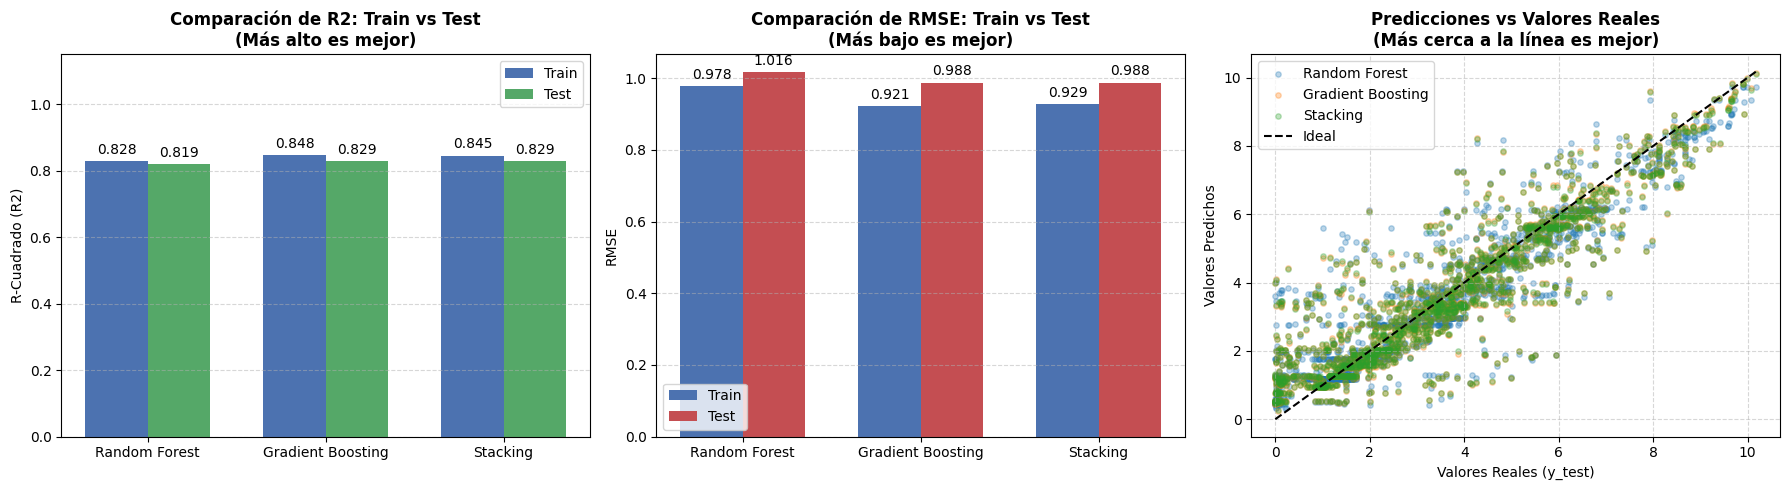

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos los modelos
modelos = ['Random Forest', 'Gradient Boosting', 'Stacking']

# 2. Extraemos los R2 exactos usando tus variables ya calculadas
r2_train = [r2_score(y_train, rf_pred_train), r2_score(y_train, gb_pred_train), r2_score(y_train, stacking_pred_train)]
r2_test  = [r2_score(y_test, rf_pred_test), r2_score(y_test, gb_pred_test), r2_score(y_test, stacking_pred_test)]

# 3. Extraemos los RMSE exactos usando tus variables ya calculadas
rmse_train = [np.sqrt(mean_squared_error(y_train, rf_pred_train)), np.sqrt(mean_squared_error(y_train, gb_pred_train)), np.sqrt(mean_squared_error(y_train, stacking_pred_train))]
rmse_test  = [np.sqrt(mean_squared_error(y_test, rf_pred_test)), np.sqrt(mean_squared_error(y_test, gb_pred_test)), np.sqrt(mean_squared_error(y_test, stacking_pred_test))]

# --- CONFIGURACIÓN DE LOS GRÁFICOS ---
x = np.arange(len(modelos))
width = 0.35

# Creamos una figura con 3 subplots en fila
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- Gráfico 1: R-Cuadrado (Barras Agrupadas) ---
# 1. Guardamos las barras en variables (bars1_train y bars1_test)
bars1_train = ax1.bar(x - width/2, r2_train, width, label='Train', color='#4C72B0')
bars1_test = ax1.bar(x + width/2, r2_test, width, label='Test', color='#55A868')

# 2. Agregamos las etiquetas de datos (fmt='%.3f' muestra 3 decimales)
ax1.bar_label(bars1_train, fmt='%.3f', padding=3)
ax1.bar_label(bars1_test, fmt='%.3f', padding=3)

ax1.set_ylabel('R-Cuadrado (R2)')
ax1.set_title('Comparación de R2: Train vs Test\n(Más alto es mejor)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos)
# Ampliamos un poco el límite superior para que el texto no choque con el borde
ax1.set_ylim(0.0, 1.15)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 2: RMSE (Barras Agrupadas) ---
# 1. Guardamos las barras en variables
bars2_train = ax2.bar(x - width/2, rmse_train, width, label='Train', color='#4C72B0')
bars2_test = ax2.bar(x + width/2, rmse_test, width, label='Test', color='#C44E52')

# 2. Agregamos las etiquetas de datos
ax2.bar_label(bars2_train, fmt='%.3f', padding=3)
ax2.bar_label(bars2_test, fmt='%.3f', padding=3)

ax2.set_ylabel('RMSE')
ax2.set_title('Comparación de RMSE: Train vs Test\n(Más bajo es mejor)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(modelos)
# ax2.set_ylim(0.00, 1.20) # Asegúrate de que el límite permita ver los números arriba de la barra
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 3: Dispersión Real vs Predicho (Test Set) ---
# Compara cómo se alinean las predicciones del Test set con la realidad
ax3.scatter(y_test, rf_pred_test, alpha=0.3, label='Random Forest', s=15)
ax3.scatter(y_test, gb_pred_test, alpha=0.3, label='Gradient Boosting', s=15)
ax3.scatter(y_test, stacking_pred_test, alpha=0.3, label='Stacking', s=15)

# Línea de predicción perfecta
min_val = min(y_test.min(), min(rf_pred_test.min(), gb_pred_test.min(), stacking_pred_test.min()))
max_val = max(y_test.max(), max(rf_pred_test.max(), gb_pred_test.max(), stacking_pred_test.max()))
ax3.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Ideal')

ax3.set_xlabel('Valores Reales (y_test)')
ax3.set_ylabel('Valores Predichos')
ax3.set_title('Predicciones vs Valores Reales\n(Más cerca a la línea es mejor)', fontweight='bold')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 6.2.5.- Evaluación de Métricas

1. Gradient Boosting

* **Desempeño en Test:** R2 de **0.8286** y RMSE de **0.9876**.
* **Análisis:** Tiene el error más bajo y la mayor capacidad de explicación en los datos no vistos (Test). Aunque tiene un ligero nivel de sobreajuste (su R2 baja de 0.847 a 0.828 al pasar de Train a Test), esta diferencia es completamente normal y aceptable.

2. Stacking Regressor

* **Desempeño en Test:** R2 de **0.8285** y RMSE de **0.9879**.
* **Análisis:** El Stacking (que es un ensamble que combina las predicciones de varios modelos base para intentar mejorar el resultado) rinde **prácticamente igual** que el Gradient Boosting. La diferencia está en el cuarto decimal. Esto suele ocurrir cuando uno de los modelos base (en este caso, seguramente el Gradient Boosting) es tan fuerte que domina las predicciones del Stacking, haciendo que el esfuerzo computacional extra de combinarlos no aporte un beneficio real en las métricas.

3. Random Forest

* **Desempeño en Test:** R2 de **0.8186** y RMSE de **1.0161**.
* **Análisis:** Es el modelo más conservador de los tres. Queda un pequeño paso por detrás en capacidad predictiva (su error RMSE es un poco más alto, superando la barrera de 1.0), pero a cambio muestra ser sumamente robusto. Al observar la diferencia entre Train y Test, vemos que se comporta de manera muy estable.

4. Gráfico comparativo

* El gráfico de "Predicciones vs Valores Reales" respalda visualmente lo que dicen los números:

* Los puntos de los tres colores (los tres modelos) se agrupan muy bien alrededor de la línea negra punteada (la línea ideal donde la predicción es exactamente igual a la realidad).
* **Ausencia de sesgo grave:** No se ve que los modelos estén prediciendo muy por encima o muy por debajo en un rango particular, aunque sí se nota que a medida que los valores reales aumentan (hacia la derecha del gráfico), los puntos se dispersan un poco más. Esto es porque es más difícil predecir con exactitud valores extremos o muy altos que valores promedio.

5. Conclusión y recomendación

A partir de los resultados obtenidos, decidimos que el modelo más adecuado es el **Gradientt Boosting**, ya que logró los mejores resultados predictivos, y en la comparación con Stacking, requiere menor complejidad técnica y menor tiempo de procesamiento.

## 6.3.- Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# 1. Definimos la estrategia (5 particiones, mezclando los datos aleatoriamente)
kf = KFold(n_splits=5, shuffle=True, random_state=semilla)

print("=== VALIDACIÓN CRUZADA (K-Fold = 5) EN SET DE ENTRENAMIENTO ===\n")

# --- RANDOM FOREST ---
# Calculamos R2
rf_cv_r2 = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2')
# Calculamos RMSE (scikit-learn devuelve el valor negativo, por eso el signo '-' al principio)
rf_cv_rmse = -cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print("Random Forest:")
print(f"R2:   {rf_cv_r2.mean():.4f} (+/- {rf_cv_r2.std() * 2:.4f})")
print(f"RMSE: {rf_cv_rmse.mean():.4f} (+/- {rf_cv_rmse.std() * 2:.4f})\n")

# --- GRADIENT BOOSTING ---
gb_cv_r2 = cross_val_score(gb_model, X_train, y_train, cv=kf, scoring='r2')
gb_cv_rmse = -cross_val_score(gb_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print("Gradient Boosting:")
print(f"R2:   {gb_cv_r2.mean():.4f} (+/- {gb_cv_r2.std() * 2:.4f})")
print(f"RMSE: {gb_cv_rmse.mean():.4f} (+/- {gb_cv_rmse.std() * 2:.4f})")

=== VALIDACIÓN CRUZADA (K-Fold = 5) EN SET DE ENTRENAMIENTO ===

Random Forest:
R2:   0.8171 (+/- 0.0104)
RMSE: 1.0088 (+/- 0.0247)

Gradient Boosting:
R2:   0.8285 (+/- 0.0104)
RMSE: 0.9767 (+/- 0.0273)


Estos resultados confirman lo que ya sospechábamos con la prueba anterior:

Gradient Boosting es el mejor modelo: Su nota promedio en las 5 pruebas es superior (explica el 82.8% de los datos) y su margen de error (RMSE de 0.976) es el más bajo.

Excelente estabilidad: El margen de +/- 0.0104 en el R2 de ambos modelos significa que, sin importar cómo mezclemos los datos, el rendimiento apenas varía un 1%. Esto demuestra que los modelos no están memorizando los datos (no hay overfitting), sino que realmente aprendieron y pueden predecir con seguridad.

## 6.4.- Optimización de hiperparámetros

In [ ]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.4 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import numpy as np
# ==========================================
# 1. GRADIENT BOOSTING
# ==========================================

param_grid_gb_bayes = {
    'n_estimators':      Integer(100, 500),         # Cantidad de árboles
    'learning_rate':     Real(0.01, 0.3, prior='log-uniform'), # Tasa de aprendizaje
    'max_depth':         Integer(3, 10),            # Profundidad máxima de cada árbol
    'min_samples_leaf':  Integer(1, 5),             # Mínimo de muestras en una hoja final
    'min_samples_split': Integer(2, 6),             # Mínimo de muestras para dividir un nodo
    'subsample':         Real(0.6, 1.0)             # Fracción de muestras para entrenar cada árbol
}

bayes_search_gb = BayesSearchCV(
    estimator=GradientBoostingRegressor(random_state=semilla),
    search_spaces=param_grid_gb_bayes,
    n_iter=20,                              # Iteraciones de búsqueda bayesiana
    cv=kf,                                  # Folds para evaluar cada combinación (KFold=5)
    scoring='neg_mean_squared_error',       # Usamos MSE negativo para luego calcular la raíz
    n_jobs=-1,                              # Paraleliza el entrenamiento
    random_state=semilla,                   # Reproducibilidad
    verbose=1                               # Muestra progreso en consola
)

print("Entrenando Gradient Boosting...")
bayes_search_gb.fit(X_train, y_train)

print("\n=== Resultados de Bayesian Search (Gradient Boosting) ===")
print(f"Mejores hiperparámetros: {bayes_search_gb.best_params_}")
print(f"Mejor RMSE en CV: {np.sqrt(-bayes_search_gb.best_score_):.4f}")

# ---------------------------------------------------------
# Extracción de los mejores modelos listos para usar
# ---------------------------------------------------------
best_gb_model = bayes_search_gb.best_estimator_

Entrenando Gradient Boosting...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each

In [ ]:
# 1. Extraemos el mejor modelo directamente de la búsqueda bayesiana
gb_model_optimizado = bayes_search_gb.best_estimator_

# 2. Entrenamos
gb_model_optimizado.fit(X_train, y_train)

# 3. Predecimos
gb_pred_train_opt = gb_model_optimizado.predict(X_train)
gb_pred_test_opt = gb_model_optimizado.predict(X_test)

# 4. Evaluamos
print("Resultados Gradient Boosting (Optimizado Automáticamente):")
calcular_metricas(y_train, gb_pred_train_opt, "Gradient Boosting Optimizado", "TRAIN")
calcular_metricas(y_test, gb_pred_test_opt, "Gradient Boosting Optimizado", "TEST")

# 5. Mostramos los hiperparámetros ganadores (para que queden registrados en el output)
print("\nLos hiperparámetros ganadores fueron:")
print(bayes_search_gb.best_params_)
print()

# Mostramos el objeto final
gb_model_optimizado

Resultados Gradient Boosting (Optimizado Automáticamente):
--- Gradient Boosting Optimizado (TRAIN) ---
MAE:  0.6367
MSE:  0.9052
RMSE: 0.9514
R2:   0.8375

--- Gradient Boosting Optimizado (TEST) ---
MAE:  0.6614
MSE:  0.9629
RMSE: 0.9813
R2:   0.8308


Los hiperparámetros ganadores fueron:
OrderedDict({'learning_rate': 0.07493340906486633, 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 100, 'subsample': 0.6})



GradientBoostingRegressor(learning_rate=0.07493340906486633, min_samples_leaf=5,
                          min_samples_split=6, random_state=7, subsample=0.6)

Resultados de la optimización:

La métrica R2 dio casi exactamente lo mismo en Train (0.8375) y en Test (0.8308). Significa que el modelo no se "aprendió de memoria" los datos de entrenamiento, sino que realmente entendió las reglas del juego. Con esto descartamos overfitting (sobreajuste).

El margen de error (RMSE) se mantuvo consistente en todas las etapas. Nos dio 0.97 en la validación cruzada (CV), 0.95 en el entrenamiento, y 0.98 en la prueba. Esto nos da seguridad de cómo se va a comportar con datos nuevos en el futuro.

Los hiperparámetros definidos (usar solo el 60% de los datos por árbol y limitar la profundidad a 3) funcionaron como un freno. Evitaron que el modelo se vuelva innecesariamente complejo y aseguraron esta gran estabilidad.

#7.- Conclusión Final

### Conclusión Final del Proyecto

El objetivo central de este trabajo práctico fue desarrollar un modelo capaz de predecir la cantidad de energía anual que produce una central eléctrica (`generation_gwh_2016_log`). Ante un escenario de planificación sobre el uso de la energía, buscamos entender qué variables impulsan la generación, respaldando el analisis con datos.

A partir de estos datos, buscamos responder a la pregunta: *Si conocemos las características físicas y geográficas de una planta, ¿podemos anticipar con exactitud cuánta energía va a inyectar a la red?* La respuesta resultó ser un contundente sí.

**Principales Descubrimientos**

A través del análisis estadístico y la construcción de modelos, logramos aislar y cuantificar los factores determinantes en la producción eléctrica:

* El tamaño de la infraestructura instalada (`capacity_mw_log`) es el predictor definitivo.
Existe una relación directa y proporcional: a mayor capacidad instalada, mayor es la energía generada de manera casi lineal.
* No todos los combustibles rinden igual en el acumulado anual. Las tecnologías de base (como la energía Nuclear o el procesamiento de Residuos), diseñadas para operar sin interrupciones, mostraron los mayores niveles de generación. En contraste, tecnologías intermitentes (como la Solar y Eólica) generan volúmenes menores debido a sus restricciones operativas o climáticas.
* El contexto geográfico importa. Al escalar el análisis a la base de datos completa, se evidenció que el país de radicación influye significativamente. Esto se debe a factores como la calidad de la red eléctrica nacional, la demanda constante y las políticas de estado optimizan la producción real de las plantas.

**El Éxito Predictivo a Nivel Técnico**

Desde el punto de vista metodológico, el proyecto validó con éxito el uso de herramientas avanzadas de Machine Learning para resolver este problema:

* Los modelos lograron capturar y explicar más del **82% de la varianza** en la generación de energía, un nivel de precisión excelente para un conjunto de datos del mundo real.
* Tras someter las predicciones a pruebas de Validación Cruzada, el algoritmo **Gradient Boosting** se consolidó como el ganador indiscutido. Logró el equilibrio perfecto: el margen de error más bajo (RMSE), la mejor adaptación a datos nuevos (Test) y una estabilidad notable frente a distintas muestras, todo esto manteniendo una eficiencia computacional superior a ensambles más complejos como el Stacking.


En definitiva, este trabajo demuestra que la generación de energía es un fenómeno altamente descriptible y predecible a través de los datos. Conociendo apenas tres pilares fundamentales (tamaño, tipo de combustible y ubicación), logramos construir un modelo analítico capaz de estimar la producción eléctrica con alto nivel de exactitud, convirtiéndose en un gran punto de partida para cualquier análisis orientado a la inversión, gestión o estudio del sector energético.